In [76]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FixedLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore")

In [77]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 10
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8.5})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = True

In [78]:
results_file = 'overall_results_2050.xlsx'

In [79]:
economics_one_five_step_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'economics_1-step_vs_5-step', index_col = 0)
economics_one_five_step_df_final = economics_one_five_step_df.drop(columns = ['Total', 'Low', 'High'])
economics_one_five_step_df_final

,Scenario,Ammonia,Electricity,Heating,Cooling,CAPEX,Direct emissions
0,1-step,0.755786,0.004700,0.000000,0.002308,0.032696,0
1,5-step,0.825962,0.051168,0.001908,0.006606,0.139513,0
2,1-step,0.757260,0.004700,0.000000,0.002308,0.032696,0
3,5-step,0.827574,0.051168,0.001908,0.006606,0.139513,0


In [80]:
economics_N_H_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'economics_N_vs_H', index_col = 0)
economics_N_H_df_final = economics_N_H_df.drop(columns = ['Total', 'Low', 'High'])
economics_N_H_df_final

,Scenario,Ammonia,Hydrogen,2-Ethylanthraquinone,Electricity,Heating,Cooling,CAPEX,Direct emissions
0,N2O,0.755786,0.000,0.000000,0.004700,0.000000,0.002308,0.032696,0
1,H2O2,0.000000,0.154,1.457296,0.008276,0.013849,0.001429,0.036481,0
2,N2O,0.757260,0.000,0.000000,0.004700,0.000000,0.002308,0.032696,0
3,H2O2,0.000000,0.230,1.457296,0.008276,0.013849,0.001429,0.036481,0


In [81]:
climate_change_one_five_step_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'climate_change_1-step_vs_5-step', index_col = 0)
climate_change_one_five_step_df_final = climate_change_one_five_step_df.drop(columns = ['Total'])
climate_change_one_five_step_df_final

,Scenario,Ammonia,Electricity,Heating,Cooling,CAPEX,Direct emissions
0,1-step,2.662957,0.000280,0.000000,0.000412,0,0
1,5-step,2.910219,0.003054,0.019472,0.000469,0,0
2,1-step,0.209760,0.000280,0.000000,0.000412,0,0
3,5-step,0.252231,0.003054,0.019472,0.000469,0,0


In [82]:
climate_change_N_H_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'climate_change_N_vs_H', index_col = 0)
climate_change_N_H_df_final = climate_change_N_H_df.drop(columns = ['Total'])
climate_change_N_H_df_final

,Scenario,Ammonia,Hydrogen,2-Ethylanthraquinone,Electricity,Heating,Cooling,CAPEX,Direct emissions
0,N2O,2.662957,0.000000,0.000000,0.000280,0.000000,0.000412,0,0.000000
1,H2O2,0.000000,0.862772,0.070901,0.000494,0.133475,0.000176,0,0.081328
2,N2O,0.209760,0.000000,0.000000,0.000280,0.000000,0.000412,0,0.000000
3,H2O2,0.000000,0.084306,0.070901,0.000494,0.133475,0.000176,0,0.081328


In [83]:
x_pts_steps = np.arange(0, len(climate_change_one_five_step_df))
x_labels_steps = ['1-step', '5-step'] * 2
colors_steps = ['#f75e84', '#f8961e', '#f9c74f', '#90be6d', '#43aa8b', '#039cf0'] 

In [84]:
x_pts_N_H = np.arange(0, len(climate_change_N_H_df))
x_labels_N_H = ['N$_\mathdefault{2}$O', 'H$_\mathdefault{2}$O$_\mathdefault{2}$'] * 2
colors_N_H = ['#f75e84', '#f78c6b', '#ffd166', '#83d483', '#06d6a0', '#0cb0a9', '#039cf0', '#0073d2'] 

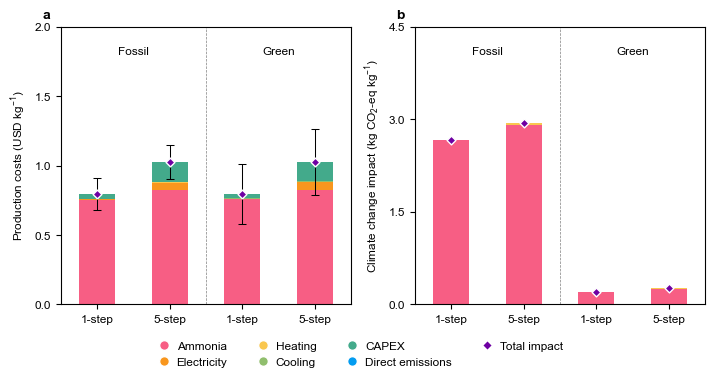

In [85]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (fig_length[2], fig_height*0.35))

economics_one_five_step_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_steps, alpha=1)
ax1.legend([], frameon = False)
ax1.set_ylabel('Production costs (USD kg$^\mathdefault{-1}$)')
ax1.scatter(x_pts_steps, economics_one_five_step_df['Total'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax1.set_title('a', fontweight='bold', x = -0.05, fontsize = fontsize_title)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.errorbar(
    x_pts_steps,
    economics_one_five_step_df['Total'],
    yerr = (economics_one_five_step_df['Total'] - economics_one_five_step_df['Low'], economics_one_five_step_df['High'] - economics_one_five_step_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 0.75,
    capsize = 3,
    capthick = 0.75,
    zorder = 1,
)
ax1.set_ylim([0.0, 2.0])
ax1.text(0.5, 2*0.9, 'Fossil', ha = 'center', color = '#000000')
ax1.text(2.5, 2*0.9, 'Green', ha = 'center', color = '#000000')
ax1.yaxis.set_major_locator(MaxNLocator(4))
ax1.set_xticks(x_pts_steps)  
ax1.set_xticklabels(x_labels_steps, rotation = 0, ha = 'center')  

climate_change_one_five_step_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors_steps, alpha=1)
ax2.legend([], frameon = False)
ax2.set_ylabel('Climate change impact (kg CO$_\mathdefault{2}$-eq kg$^\mathdefault{-1}$)')
ax2.scatter(x_pts_steps, climate_change_one_five_step_df['Total'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax2.set_title('b', fontweight='bold', x = -0.05, fontsize = fontsize_title)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax2.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)

ax2.set_ylim([0, 4.5])
ax2.text(0.5, 4.5*0.9, 'Fossil', ha = 'center', color = '#000000')
ax2.text(2.5, 4.5*0.9, 'Green', ha = 'center', color = '#000000')
ax2.yaxis.set_major_locator(MaxNLocator(4))
ax2.set_xticks(x_pts_steps)  
ax2.set_xticklabels(x_labels_steps, rotation = 0, ha = 'center')  

labels = ['Ammonia', 'Electricity', 'Heating', 'Cooling', 'CAPEX', 'Direct emissions', 'Total impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7, alpha=1, linewidth=0.0) for color in colors_steps]
# handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 4, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'results', 'plots', 'supplementary', '1_step_vs_5_step_raw')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

# filepath = os.path.join('..', 'results', 'plots', 'edited', '1_step_vs_5_step_edited')
# plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
# plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

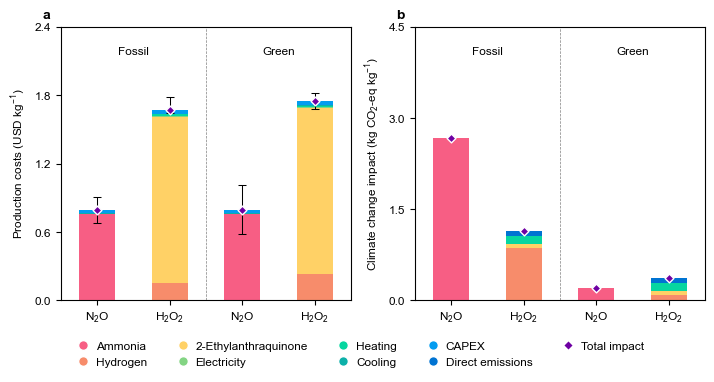

In [86]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (fig_length[2], fig_height*0.35))

economics_N_H_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_N_H, alpha=1)
ax1.legend([], frameon = False)
ax1.set_ylabel('Production costs (USD kg$^\mathdefault{-1}$)')
ax1.scatter(x_pts_N_H, economics_N_H_df['Total'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax1.set_title('a', fontweight='bold', x = -0.05, fontsize = fontsize_title)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.errorbar(
    x_pts_N_H,
    economics_N_H_df['Total'],
    yerr = (economics_N_H_df['Total'] - economics_N_H_df['Low'], economics_N_H_df['High'] - economics_N_H_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 0.75,
    capsize = 3,
    capthick = 0.75,
    zorder = 1,
)
ax1.set_ylim([0.0, 2.4])
ax1.text(0.5, 2.4*0.9, 'Fossil', ha = 'center', color = '#000000')
ax1.text(2.5, 2.4*0.9, 'Green', ha = 'center', color = '#000000')
ax1.yaxis.set_major_locator(MaxNLocator(4))
ax1.set_xticks(x_pts_N_H)  
ax1.set_xticklabels(x_labels_N_H, rotation = 0, ha = 'center')  

climate_change_N_H_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors_N_H, alpha=1)
ax2.legend([], frameon = False)
ax2.set_ylabel('Climate change impact (kg CO$_\mathdefault{2}$-eq kg$^\mathdefault{-1}$)')
ax2.scatter(x_pts_N_H, climate_change_N_H_df['Total'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax2.set_title('b', fontweight='bold', x = -0.05, fontsize = fontsize_title)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax2.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.set_ylim([0, 4.5])
ax2.text(0.5, 4.5*0.9, 'Fossil', ha = 'center', color = '#000000')
ax2.text(2.5, 4.5*0.9, 'Green', ha = 'center', color = '#000000')
ax2.yaxis.set_major_locator(MaxNLocator(4))
ax2.set_xticks(x_pts_N_H)  
ax2.set_xticklabels(x_labels_N_H, rotation = 0, ha = 'center')  

labels = ['Ammonia', 'Hydrogen', '2-Ethylanthraquinone', 'Electricity', 'Heating', 'Cooling', 'CAPEX', 'Direct emissions', 'Total impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7, alpha=1, linewidth=0.0) for color in colors_N_H]
# handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 5, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'results', 'plots', 'supplementary', 'nitrous_oxide_vs_hydrogen_peroxide_raw')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

# filepath = os.path.join('..', 'results', 'plots', 'edited', 'nitrous_oxide_vs_hydrogen_peroxide_edited')
# plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
# plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

In [87]:
economics_phenol_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'economics_phenol', index_col = 0)
economics_phenol_df_final = economics_phenol_df.drop(columns = ['Total', 'Low', 'High'])
economics_phenol_df_final

,Scenario,Cumene oxidation,Benzene,Nitrous oxide,Hydrogen peroxide,Heating,Cooling,CAPEX,Direct emissions
0,BAU,1.521862,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0
1,N2O,0.000000,0.662796,0.377895,0.00000,0.078184,0.000500,0.047294,0
2,H2O2,0.000000,0.737750,0.000000,0.80070,0.042342,0.002525,0.065736,0
3,N2O,0.000000,0.662796,0.378846,0.00000,0.078184,0.000500,0.047294,0
4,H2O2,0.000000,0.737750,0.000000,0.83723,0.042342,0.002525,0.065736,0


In [88]:
climate_change_phenol_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'climate_change_phenol', index_col = 0)
climate_change_phenol_df_final = climate_change_phenol_df.drop(columns = ['Total'])
climate_change_phenol_df_final

,Scenario,Cumene oxidation,Benzene,Nitrous oxide,Hydrogen peroxide,Heating,Cooling,CAPEX,Direct emissions
0,BAU,4.470192,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000e+00
1,N2O,0.000000,1.642123,1.266032,0.000000,0.886513,0.000003,0,1.365000e-01
2,H2O2,0.000000,1.827841,0.000000,0.550440,0.480107,0.000094,0,3.905283e-08
3,N2O,0.000000,1.642123,0.100028,0.000000,0.886513,0.000003,0,1.365000e-01
4,H2O2,0.000000,1.827841,0.000000,0.177555,0.480107,0.000094,0,3.905283e-08


In [89]:
x_pts_phenol = np.arange(0, len(climate_change_phenol_df))
x_labels_phenol = ['Cumene\noxidation', 'N$_\mathdefault{2}$O', 'H$_\mathdefault{2}$O$_\mathdefault{2}$', 'N$_\mathdefault{2}$O', 'H$_\mathdefault{2}$O$_\mathdefault{2}$']
colors_phenol = ['#808080', '#f75e84', '#f78c6b', '#ffd166', '#83d483', '#06d6a0', '#0cb0a9', '#039cf0'] 

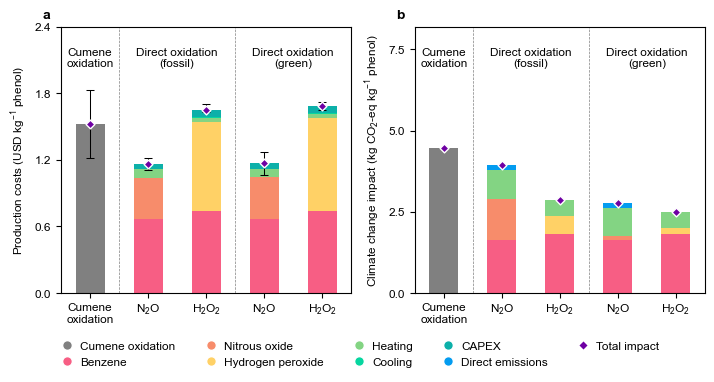

In [90]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (fig_length[2], fig_height*0.35))

economics_phenol_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_phenol, alpha=1)
ax1.legend([], frameon = False)
ax1.set_ylabel('Production costs (USD kg$^\mathdefault{-1}$ phenol)')
ax1.scatter(x_pts_phenol, economics_phenol_df['Total'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax1.set_title('a', fontweight='bold', x = -0.05, fontsize = fontsize_title)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.errorbar(
    x_pts_phenol,
    economics_phenol_df['Total'],
    yerr = (economics_phenol_df['Total'] - economics_phenol_df['Low'], economics_phenol_df['High'] - economics_phenol_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 0.75,
    capsize = 3,
    capthick = 0.75,
    zorder = 1,
)
ax1.set_ylim([0.0, 2.4])
ax1.text(0, 2.4*0.85, 'Cumene\noxidation', ha = 'center', color = '#000000')
ax1.text(1.5, 2.4*0.85, 'Direct oxidation\n(fossil)', ha = 'center', color = '#000000')
ax1.text(3.5, 2.4*0.85, 'Direct oxidation\n(green)', ha = 'center', color = '#000000')
ax1.yaxis.set_major_locator(MaxNLocator(4))
ax1.set_xticks(x_pts_phenol)  
ax1.set_xticklabels(x_labels_phenol, rotation = 0, ha = 'center')  

climate_change_phenol_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors_phenol, alpha=1)
ax2.legend([], frameon = False)
ax2.set_ylabel('Climate change impact (kg CO$_\mathdefault{2}$-eq kg$^\mathdefault{-1}$ phenol)')
ax2.scatter(x_pts_phenol, climate_change_phenol_df['Total'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax2.set_title('b', fontweight='bold', x = -0.05, fontsize = fontsize_title)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax2.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)

ax2.set_ylim([0, 8.2])
ax2.text(0, 8.2*0.85, 'Cumene\noxidation', ha = 'center', color = '#000000')
ax2.text(1.5, 8.2*0.85, 'Direct oxidation\n(fossil)', ha = 'center', color = '#000000')
ax2.text(3.5, 8.2*0.85, 'Direct oxidation\n(green)', ha = 'center', color = '#000000')
ax2.yaxis.set_major_locator(MaxNLocator(4))
ax2.set_xticks(x_pts_phenol)  
ax2.set_xticklabels(x_labels_phenol, rotation = 0, ha = 'center')  

labels = ['Cumene oxidation', 'Benzene', 'Nitrous oxide', 'Hydrogen peroxide', 'Heating', 'Cooling', 'CAPEX', 'Direct emissions', 'Total impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7, alpha=1, linewidth=0.0) for color in colors_phenol]
# handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 5, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'results', 'plots', 'supplementary', 'phenol_production')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

# filepath = os.path.join('..', 'results', 'plots', 'edited', 'nitrous_oxide_vs_hydrogen_peroxide_edited')
# plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
# plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)